# 节点 02：Minsky & Papert — XOR 不可分证明与多层网络的曙光

本 notebook 配合 [docs/02-minsky-papert-1969.md](../docs/02-minsky-papert-1969.md) 使用。

**你将手撕：**
1. 可视化 AND / OR / XOR 的线性可分性
2. 代码验证 XOR 在单层感知机上永远收敛不了
3. 手工设计一个 2 层网络，解决 XOR

## Part 1：可视化 — AND / OR / XOR 为什么不同？

/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/988438224.py:43: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/988438224.py:43: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/988438224.py:43: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/988438224.py:43: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/988438224.py:43: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaV

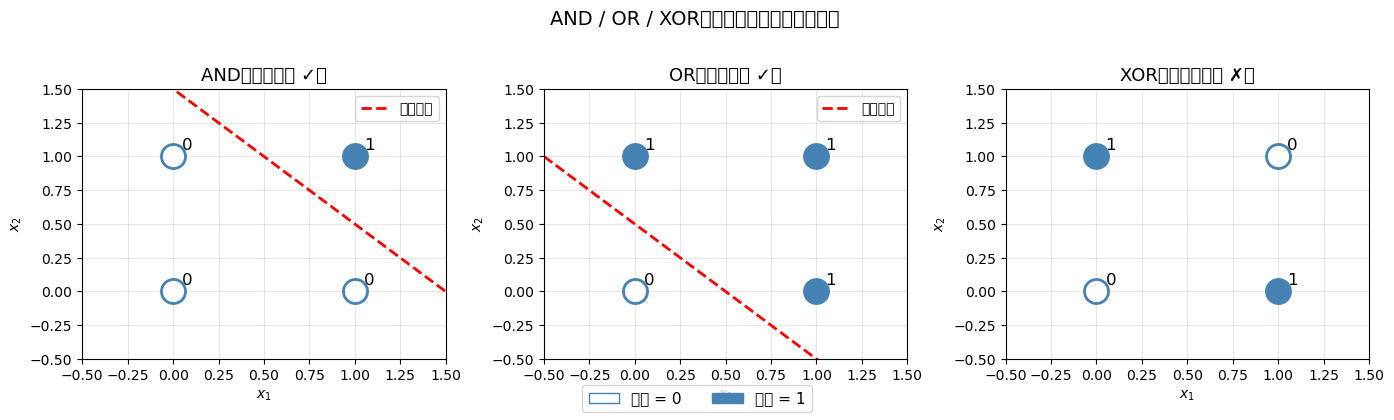

注意 XOR 图：左下=0、右上=0（空心），左上=1、右下=1（实心）。
试着脑补任何一条直线——都不可能同时把它们分开。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('../docs/assets', exist_ok=True)

# 定义 3 种逻辑函数的真值表
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

y_AND = np.array([0, 0, 0, 1])
y_OR  = np.array([0, 1, 1, 1])
y_XOR = np.array([0, 1, 1, 0])

def plot_problem(ax, X, y, title, boundary_params=None):
    colors = ['white' if label == 0 else 'steelblue' for label in y]
    for (x1, x2), c, label in zip(X, colors, y):
        ax.scatter(x1, x2, s=300, c=c, edgecolors='steelblue', linewidths=2, zorder=5)
        ax.text(x1 + 0.05, x2 + 0.05, str(label), fontsize=12)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    if boundary_params:
        w1, w2, b = boundary_params
        xs = np.linspace(-0.5, 1.5, 100)
        if abs(w2) > 1e-9:
            ys = -(w1 * xs + b) / w2
            ax.plot(xs, ys, 'r--', linewidth=2, label='决策边界')
            ax.legend(fontsize=10)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_problem(axes[0], X, y_AND, 'AND（线性可分 ✓）', boundary_params=(1, 1, -1.5))
plot_problem(axes[1], X, y_OR,  'OR（线性可分 ✓）',  boundary_params=(1, 1, -0.5))
plot_problem(axes[2], X, y_XOR, 'XOR（线性不可分 ✗）')

blue = mpatches.Patch(facecolor='steelblue', edgecolor='steelblue', label='输出 = 1')
white = mpatches.Patch(facecolor='white', edgecolor='steelblue', label='输出 = 0')
fig.legend(handles=[white, blue], loc='lower center', ncol=2, fontsize=11)
plt.suptitle('AND / OR / XOR：哪个能被一条直线分开？', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/assets/02-xor-separability.png', dpi=100, bbox_inches='tight')
plt.show()
print('注意 XOR 图：左下=0、右上=0（空心），左上=1、右下=1（实心）。')
print('试着脑补任何一条直线——都不可能同时把它们分开。')

## Part 2：代码验证 — 训练单层感知机解 XOR，会发生什么？

我们用节点 01 里学过的感知机学习规则，让它「努力」学 XOR，看看会怎样。

/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2679187809.py:44: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2679187809.py:44: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2679187809.py:44: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2679187809.py:44: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2679187809.py:44: UserWarning: Glyph 38169 (\N{CJK UNIFIED IDEOGRAPH-9519}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4

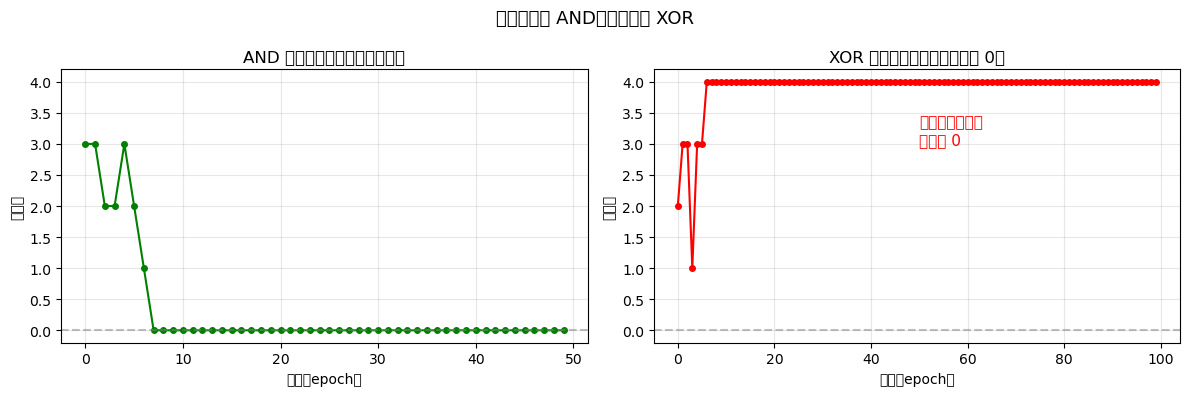

AND 最终权重：w=[0.17 0.14], b=-0.24
AND 最终错误数：0
XOR 最终错误数：4（不为零，说明没有收敛）


In [2]:
def step(x):
    return 1 if x > 0 else 0

def train_perceptron(X, y, epochs=100, lr=0.1, seed=42):
    rng = np.random.default_rng(seed)
    w = rng.uniform(-0.5, 0.5, size=X.shape[1])
    b = rng.uniform(-0.5, 0.5)
    errors_per_epoch = []
    for _ in range(epochs):
        errors = 0
        for xi, yi in zip(X, y):
            pred = step(np.dot(w, xi) + b)
            delta = lr * (yi - pred)
            w += delta * xi
            b += delta
            if pred != yi:
                errors += 1
        errors_per_epoch.append(errors)
    return w, b, errors_per_epoch

w_and, b_and, err_and = train_perceptron(X, y_AND, epochs=50)
w_xor, b_xor, err_xor = train_perceptron(X, y_XOR, epochs=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(err_and, 'g-o', markersize=4)
ax1.set_title('AND 的训练误差（每轮错误数）')
ax1.set_xlabel('轮次（epoch）')
ax1.set_ylabel('错误数')
ax1.set_ylim(-0.2, 4.2)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)

ax2.plot(err_xor, 'r-o', markersize=4)
ax2.set_title('XOR 的训练误差（永远不会到 0）')
ax2.set_xlabel('轮次（epoch）')
ax2.set_ylabel('错误数')
ax2.set_ylim(-0.2, 4.2)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.text(50, 3, '误差永远在震荡\n永不为 0', color='red', fontsize=11)

plt.suptitle('感知机能学 AND，但学不了 XOR', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/assets/02-xor-training.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'AND 最终权重：w={w_and.round(2)}, b={b_and:.2f}')
print(f'AND 最终错误数：{err_and[-1]}')
print(f'XOR 最终错误数：{err_xor[-1]}（不为零，说明没有收敛）')

## Part 3：代数验证 — 不等式矛盾

用程序枚举法验证：在所有可能的参数组合中，真的找不到能同时满足 XOR 所有 4 个条件的解。

In [3]:
def is_linearly_separable(X, y, search_range=(-5, 5), steps=50):
    vals = np.linspace(search_range[0], search_range[1], steps)
    for w1 in vals:
        for w2 in vals:
            for b in vals:
                all_correct = all(
                    step(w1 * xi[0] + w2 * xi[1] + b) == yi
                    for xi, yi in zip(X, y)
                )
                if all_correct:
                    return True, (w1, w2, b)
    return False, None

print('正在搜索 AND 的线性分类器...')
ok_and, params_and = is_linearly_separable(X, y_AND)
print(f'AND 线性可分：{ok_and}，参数示例：{params_and}')

print('\n正在搜索 OR 的线性分类器...')
ok_or, params_or = is_linearly_separable(X, y_OR)
print(f'OR 线性可分：{ok_or}，参数示例：{params_or}')

print('\n正在搜索 XOR 的线性分类器（需要一点时间）...')
ok_xor, params_xor = is_linearly_separable(X, y_XOR)
print(f'XOR 线性可分：{ok_xor}，参数：{params_xor}')

if not ok_xor:
    print('\n验证通过：找不到能正确分类 XOR 的单层感知机。')
    print('这与 Minsky & Papert (1969) 的数学证明完全一致。')

正在搜索 AND 的线性分类器...
AND 线性可分：True，参数示例：(0.1020408163265305, 0.1020408163265305, -0.1020408163265305)

正在搜索 OR 的线性分类器...
OR 线性可分：True，参数示例：(0.3061224489795915, 0.3061224489795915, -0.1020408163265305)

正在搜索 XOR 的线性分类器（需要一点时间）...


XOR 线性可分：False，参数：None

验证通过：找不到能正确分类 XOR 的单层感知机。
这与 Minsky & Papert (1969) 的数学证明完全一致。


## Part 4：解法 — 手工设计一个 2 层网络解 XOR

**思路：XOR = (OR) AND NOT (AND)**

- 隐藏节点 h1：计算 OR（只要 x1 或 x2 其中一个为 1 就激活）
- 隐藏节点 h2：计算 AND（需要 x1 和 x2 都为 1 才激活）
- 输出：h1=1 且 h2=0 时输出 1，否则输出 0

```
输入层    隐藏层         输出层
 x1  --+
        +--> h1 (OR)  --+
 x2  --+                +--> y (XOR)
        +--> h2 (AND) --+
```

In [4]:
# 手工设计的 2 层网络权重（无需训练）

# 第一层：W1 形状 (2 个隐藏节点, 2 个输入)
# h1 = step(1*x1 + 1*x2 - 0.5)  → OR（x1+x2 > 0.5 时激活）
# h2 = step(1*x1 + 1*x2 - 1.5)  → AND（x1+x2 > 1.5 时激活）
W1 = np.array([[1.0, 1.0],
               [1.0, 1.0]])
b1 = np.array([-0.5, -1.5])

# 第二层：y = step(1*h1 + (-2)*h2 - 0.5)
# 若 h1=1, h2=0：1 - 0 - 0.5 = 0.5 > 0 → 输出 1
# 若 h1=1, h2=1：1 - 2 - 0.5 = -1.5 <= 0 → 输出 0
W2 = np.array([1.0, -2.0])
b2 = -0.5

def two_layer_xor(x):
    z1 = W1 @ x + b1
    h = np.array([step(z) for z in z1])
    z2 = np.dot(W2, h) + b2
    return step(z2), h

print('验证 2 层网络的 XOR 输出：\n')
print(f'{"输入":12} {"隐藏层 h":<15} {"预测":8} {"真实":8} {"正确"}')
print('-' * 55)
all_correct = True
for (x1, x2), yi in zip(X, y_XOR):
    pred, h = two_layer_xor(np.array([x1, x2]))
    correct = (pred == yi)
    if not correct:
        all_correct = False
    mark = 'OK' if correct else 'FAIL'
    print(f'({x1}, {x2})       {str(h):<15} {pred:<8} {yi:<8} {mark}')

print()
assert all_correct, '2 层网络有错误，请检查权重！'
print('全部正确！2 层网络成功解决 XOR。')

验证 2 层网络的 XOR 输出：

输入           隐藏层 h           预测       真实       正确
-------------------------------------------------------
(0, 0)       [0 0]           0        0        OK
(0, 1)       [1 0]           1        1        OK
(1, 0)       [1 0]           1        1        OK
(1, 1)       [1 1]           0        0        OK

全部正确！2 层网络成功解决 XOR。


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2271666577.py:21: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2271666577.py:21: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2271666577.py:21: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2271666577.py:21: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_90442/2271666577.py:21: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4g

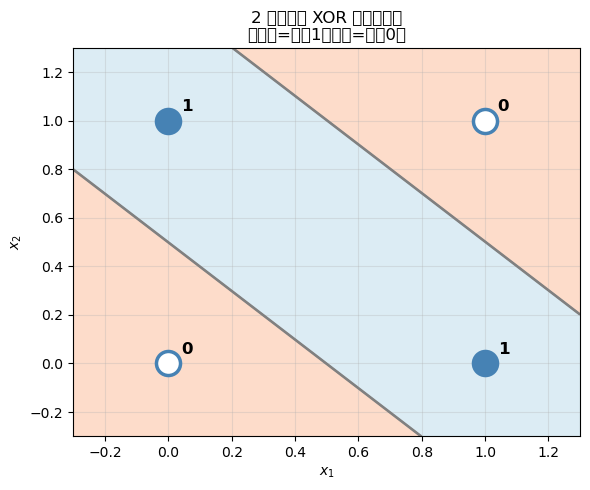

2 层网络的决策边界不是直线，而是多个折线区域的组合。
这就是为什么多层网络能解决线性不可分的问题。


In [5]:
# 可视化：2 层网络的决策边界
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 300), np.linspace(-0.3, 1.3, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]
preds = np.array([two_layer_xor(p)[0] for p in grid_points]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, preds, alpha=0.3, cmap='RdYlBu', levels=1)
ax.contour(xx, yy, preds, colors='gray', linewidths=1.5, levels=1)

for (x1, x2), yi in zip(X, y_XOR):
    color = 'steelblue' if yi == 1 else 'white'
    ax.scatter(x1, x2, s=300, c=color, edgecolors='steelblue', linewidths=2.5, zorder=5)
    ax.text(x1 + 0.04, x2 + 0.04, str(yi), fontsize=12, fontweight='bold')

ax.set_title('2 层网络对 XOR 的决策区域\n（蓝色=预测1，红色=预测0）', fontsize=12)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/assets/02-xor-2layer-boundary.png', dpi=100, bbox_inches='tight')
plt.show()
print('2 层网络的决策边界不是直线，而是多个折线区域的组合。')
print('这就是为什么多层网络能解决线性不可分的问题。')

## 总结

| 问题 | 单层感知机 | 2 层网络 |
|------|----------|----------|
| AND  | 可解     | 可解     |
| OR   | 可解     | 可解     |
| XOR  | **不可解** | **可解** |

**关键洞察：**
- 单层感知机 = 在平面上画一条直线；XOR 对角分布，无法被直线分开
- 多层网络 = 组合多个判断，能形成折线形的决策边界
- 问题不在于网络大小，而在于怎么训练多层网络——这个问题直到 1986 年反向传播才解决

*参考文献：Minsky, M., & Papert, S. (1969). Perceptrons. MIT Press. ISBN 978-0-262-63-070-2*